# Water Station Coverage Analysis

**Goal:** Determine which Waterweb monitoring stations are near our scope regions.

## Analysis Steps:
1. Load scope regions from `wocu_output_fase2_v4_w_wfs.gpkg` (12,130 regions)
2. Load water station locations from RWS Waterweb
3. Calculate which stations fall within/near each scope region (with buffer)
4. Analyze coverage statistics
5. Visualize on interactive map

---

## Setup

In [1]:
import sys
sys.path.append("../")

import src.paths as PATHS
import src.constants as CONST

import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Point
import csv
import re

print("✅ Imports complete!")

✅ Imports complete!


## Configuration

In [7]:
# Input GeoPackage with scope regions
INPUT_GPKG = "wocu_output_fase2_v4_w_wfs.gpkg"
input_path = PATHS.DATA_DIR / INPUT_GPKG

# Water station locations CSV
WATERWEB_CSV = Path("../scripts/waterweb_locations.csv")

# Buffer distances to test (in meters)
# Similar to DataCollector, but larger for water influence
BUFFER_DISTANCES = [
    0, # no buffer
    100,    # Very close (0.1 km)
    500,    # Close (0.5 km)
    1000,   # Near (1 km)
    5000,   # Regional (5 km)
]

print(f"📂 Input: {input_path}")
print(f"📊 Buffer distances: {BUFFER_DISTANCES} meters")
print(f"🗺️  Water stations CSV: {WATERWEB_CSV}")

📂 Input: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/wocu_output_fase2_v4_w_wfs.gpkg
📊 Buffer distances: [0, 100, 500, 1000, 5000] meters
🗺️  Water stations CSV: ../scripts/waterweb_locations.csv


---

## Load Scope Regions

In [8]:
# Load scope regions (vlakken_scope)
print("📍 Loading scope regions...")
scope_regions = gpd.read_file(input_path, layer="vlakken_scope")

print(f"✅ Loaded {len(scope_regions):,} scope regions")
print(f"📐 CRS: {scope_regions.crs}")
print(f"\n🗂️  Columns: {list(scope_regions.columns)}")

# Identify the ID column
id_col = None
for possible_id in ['location_id', 'position_id', 'region_id', 'id']:
    if possible_id in scope_regions.columns:
        id_col = possible_id
        break

print(f"🔑 ID column: '{id_col}'")

scope_regions.head(3)

📍 Loading scope regions...
✅ Loaded 12,130 scope regions
📐 CRS: EPSG:28992

🗂️  Columns: ['position_id', 'waterlichaam', 'geometry']
🔑 ID column: 'position_id'


,position_id,waterlichaam,geometry
0,rijn_l_10343_10350,"Boven-Rijn, Waal, Boven-Merwede, Beneden-Merwe...","POLYGON ((119484.028 425575.146, 119552 425573..."
1,rijn_r_10343_10350,"Boven-Rijn, Waal, Boven-Merwede, Beneden-Merwe...","POLYGON ((119552 425573, 119484.028 425575.146..."
2,rijn_l_10350_10360,"Boven-Rijn, Waal, Boven-Merwede, Beneden-Merwe...","POLYGON ((119384.07 425578.303, 119484.028 425..."


---

## Load Water Station Locations

In [9]:
def parse_point_geometry(point_str):
    """Extract lat, lon from 'POINT (lat lon)' string."""
    match = re.match(r'POINT \(([\-\d.]+) ([\-\d.]+)\)', point_str)
    if match:
        lat = float(match.group(1))
        lon = float(match.group(2))
        return (lat, lon)
    return None

# Load water station locations from CSV
print("🌊 Loading water station locations...")

stations = []
with open(WATERWEB_CSV, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        # Parse coordinates
        coords = parse_point_geometry(row['LON_LAT'])
        if not coords:
            continue
        
        lat, lon = coords
        
        stations.append({
            'code': row['LOCATIE_CODE'],
            'name': row.get('LOCATIE_NAAM', ''),
            'description': row.get('LOCATIE_OMSCHRIJVING', ''),
            'lat': lat,
            'lon': lon,
            'geometry': Point(lon, lat)  # Note: Point(x, y) = Point(lon, lat)
        })

# Convert to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(stations, geometry='geometry', crs='EPSG:4326')

# Transform to same CRS as scope regions (RD New, EPSG:28992)
stations_gdf = stations_gdf.to_crs(scope_regions.crs)

print(f"✅ Loaded {len(stations_gdf):,} water station locations")
print(f"📐 Transformed to CRS: {stations_gdf.crs}")

stations_gdf.head()

🌊 Loading water station locations...
✅ Loaded 18,949 water station locations
📐 Transformed to CRS: EPSG:28992


,code,name,description,lat,lon,geometry
0,genemuiden.vogeleiland.raai1.pq9,"Genemuiden, Vogeleiland, raai 1, PQ 009",,52.645198,6.014182,POINT (197434.326 517707.09)
1,westerschelde.stortvak6,"Westerschelde, stortvak 06",,51.350016,3.884948,POINT (50350.031 374500.008)
2,sasvangent.poelpolder,"Sas van Gent, Poel polder",,51.215913,3.795210,POINT (43773.977 359716.028)
3,middelplaat.2242,"Middelplaat, pt.2242",,51.367238,3.799987,POINT (44473.784 376540.969)
4,ketelmeer.8.4,"Ketelmeer, 8, 4",,52.590148,5.780161,POINT (181629.017 511469.958)


In [10]:
# Quick stats
print(f"📊 Water Station Statistics:")
print(f"   Total stations: {len(stations_gdf):,}")
print(f"   With names: {stations_gdf['name'].notna().sum():,}")
print(f"   With descriptions: {stations_gdf['description'].notna().sum():,}")
print(f"\n📍 Spatial extent:")
bounds = stations_gdf.total_bounds
print(f"   X: {bounds[0]:.0f} to {bounds[2]:.0f}")
print(f"   Y: {bounds[1]:.0f} to {bounds[3]:.0f}")

📊 Water Station Statistics:
   Total stations: 18,949
   With names: 18,949
   With descriptions: 18,949

📍 Spatial extent:
   X: -8803489 to 1698343
   Y: -356245 to 2016579


---

## Spatial Join: Find Stations Near Scope Regions

We'll test multiple buffer distances to understand coverage at different scales.

In [11]:
print("🔍 Performing spatial joins with different buffer distances...\n")

results = {}

for buffer_m in BUFFER_DISTANCES:
    print(f"{'='*80}")
    print(f"Buffer: {buffer_m}m ({buffer_m/1000:.1f} km)")
    print(f"{'='*80}")
    
    # Create buffered regions
    scope_buffered = scope_regions.copy()
    scope_buffered['geometry'] = scope_regions.geometry.buffer(buffer_m)
    
    # Spatial join: which stations fall within buffered regions?
    joined = gpd.sjoin(
        stations_gdf,
        scope_buffered[[id_col, 'geometry']],
        how='inner',
        predicate='within'
    )
    
    # Count stations per region
    stations_per_region = joined.groupby(id_col).size()
    
    # Count regions with at least one station
    regions_with_stations = len(stations_per_region)
    regions_without_stations = len(scope_regions) - regions_with_stations
    
    # Total station-region pairs
    total_pairs = len(joined)
    
    # Unique stations that cover at least one region
    unique_stations_used = joined['code'].nunique()
    
    results[buffer_m] = {
        'joined': joined,
        'stations_per_region': stations_per_region,
        'regions_with_stations': regions_with_stations,
        'regions_without_stations': regions_without_stations,
        'total_pairs': total_pairs,
        'unique_stations': unique_stations_used
    }
    
    print(f"\n📊 Results:")
    print(f"   Regions with ≥1 station: {regions_with_stations:,} ({regions_with_stations/len(scope_regions)*100:.1f}%)")
    print(f"   Regions without stations: {regions_without_stations:,} ({regions_without_stations/len(scope_regions)*100:.1f}%)")
    print(f"   Total station-region pairs: {total_pairs:,}")
    print(f"   Unique stations covering regions: {unique_stations_used:,}")
    print(f"   Avg stations per region (with stations): {stations_per_region.mean():.2f}")
    print(f"   Max stations in one region: {stations_per_region.max()}")
    print()

print(f"\n✅ Spatial analysis complete for {len(BUFFER_DISTANCES)} buffer distances!")

🔍 Performing spatial joins with different buffer distances...

Buffer: 0m (0.0 km)

📊 Results:
   Regions with ≥1 station: 724 (6.0%)
   Regions without stations: 11,406 (94.0%)
   Total station-region pairs: 968
   Unique stations covering regions: 959
   Avg stations per region (with stations): 1.34
   Max stations in one region: 50

Buffer: 100m (0.1 km)

📊 Results:
   Regions with ≥1 station: 2,871 (23.7%)
   Regions without stations: 9,259 (76.3%)
   Total station-region pairs: 4,500
   Unique stations covering regions: 1,114
   Avg stations per region (with stations): 1.57
   Max stations in one region: 156

Buffer: 500m (0.5 km)

📊 Results:
   Regions with ≥1 station: 8,534 (70.4%)
   Regions without stations: 3,596 (29.6%)
   Total station-region pairs: 27,678
   Unique stations covering regions: 1,425
   Avg stations per region (with stations): 3.24
   Max stations in one region: 202

Buffer: 1000m (1.0 km)

📊 Results:
   Regions with ≥1 station: 11,091 (91.4%)
   Regions with

---

## Coverage Summary Table

In [12]:
# Create summary table
summary_data = []
for buffer_m in BUFFER_DISTANCES:
    r = results[buffer_m]
    summary_data.append({
        'Buffer (m)': buffer_m,
        'Buffer (km)': buffer_m / 1000,
        'Regions with stations': r['regions_with_stations'],
        'Coverage (%)': f"{r['regions_with_stations']/len(scope_regions)*100:.1f}%",
        'Total pairs': r['total_pairs'],
        'Unique stations': r['unique_stations'],
        'Avg stations/region': f"{r['stations_per_region'].mean():.2f}"
    })

summary_df = pd.DataFrame(summary_data)

print("\n📊 COVERAGE SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)


📊 COVERAGE SUMMARY
 Buffer (m)  Buffer (km)  Regions with stations Coverage (%)  Total pairs  Unique stations Avg stations/region
          0          0.0                    724         6.0%          968              959                1.34
        100          0.1                   2871        23.7%         4500             1114                1.57
        500          0.5                   8534        70.4%        27678             1425                3.24
       1000          1.0                  11091        91.4%        64033             1688                5.77
       5000          5.0                  12130       100.0%       550016             3418               45.34


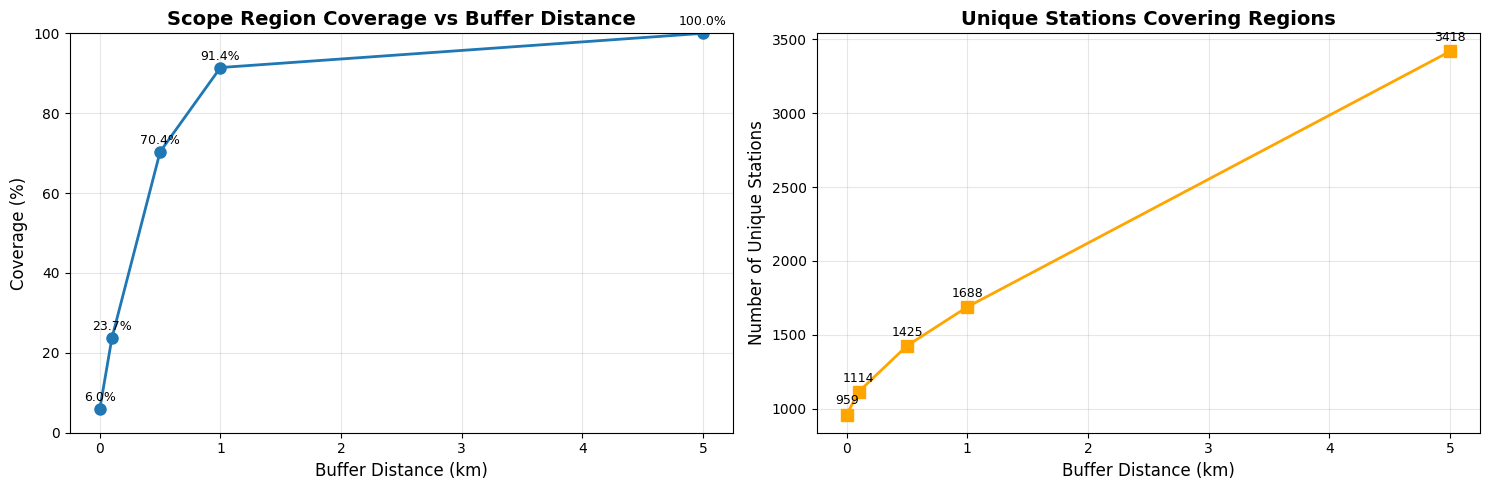

✅ Coverage analysis visualized!


In [13]:
# Visualize coverage vs buffer distance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Coverage percentage
ax1 = axes[0]
coverage_pct = [r['regions_with_stations']/len(scope_regions)*100 for r in results.values()]
ax1.plot([b/1000 for b in BUFFER_DISTANCES], coverage_pct, marker='o', linewidth=2, markersize=8)
ax1.set_xlabel('Buffer Distance (km)', fontsize=12)
ax1.set_ylabel('Coverage (%)', fontsize=12)
ax1.set_title('Scope Region Coverage vs Buffer Distance', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 100)

# Add value labels
for x, y in zip([b/1000 for b in BUFFER_DISTANCES], coverage_pct):
    ax1.text(x, y + 2, f'{y:.1f}%', ha='center', fontsize=9)

# Plot 2: Number of stations used
ax2 = axes[1]
unique_stations = [r['unique_stations'] for r in results.values()]
ax2.plot([b/1000 for b in BUFFER_DISTANCES], unique_stations, marker='s', color='orange', linewidth=2, markersize=8)
ax2.set_xlabel('Buffer Distance (km)', fontsize=12)
ax2.set_ylabel('Number of Unique Stations', fontsize=12)
ax2.set_title('Unique Stations Covering Regions', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

# Add value labels
for x, y in zip([b/1000 for b in BUFFER_DISTANCES], unique_stations):
    ax2.text(x, y + max(unique_stations)*0.02, f'{y}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Coverage analysis visualized!")

---

## Detailed Analysis: 1km Buffer

Let's focus on the 1km buffer for detailed analysis (reasonable water influence distance).

In [14]:
# Select 1km buffer results
ANALYSIS_BUFFER = 0  # meters

analysis_results = results[ANALYSIS_BUFFER]
joined_1km = analysis_results['joined']
stations_per_region_1km = analysis_results['stations_per_region']

print(f"📊 Detailed Analysis: {ANALYSIS_BUFFER}m buffer")
print(f"{'='*80}")
print(f"\n🎯 Distribution of stations per region:")
print(stations_per_region_1km.describe())

print(f"\n📈 Histogram:")
hist = stations_per_region_1km.value_counts().sort_index()
for num_stations, count in hist.items():
    bar = '█' * int(count / hist.max() * 40)
    print(f"   {num_stations:2d} stations: {count:4d} regions {bar}")

📊 Detailed Analysis: 0m buffer

🎯 Distribution of stations per region:
count    724.000000
mean       1.337017
std        2.838621
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       50.000000
dtype: float64

📈 Histogram:
    1 stations:  668 regions ████████████████████████████████████████
    2 stations:   39 regions ██
    3 stations:    4 regions 
    4 stations:    2 regions 
    6 stations:    1 regions 
    7 stations:    2 regions 
    8 stations:    1 regions 
    9 stations:    1 regions 
   10 stations:    1 regions 
   14 stations:    1 regions 
   16 stations:    1 regions 
   31 stations:    1 regions 
   44 stations:    1 regions 
   50 stations:    1 regions 


In [15]:
# Top regions with most stations
print(f"\n🏆 Top 10 regions with most stations (within {ANALYSIS_BUFFER}m):")
print(f"{'='*80}")
top_regions = stations_per_region_1km.nlargest(10)
for i, (region_id, count) in enumerate(top_regions.items(), 1):
    print(f"   {i:2d}. {region_id:40s}: {count} stations")
    # Show which stations
    region_stations = joined_1km[joined_1km[id_col] == region_id]['code'].tolist()
    print(f"       → {', '.join(region_stations[:3])}{'...' if len(region_stations) > 3 else ''}")
    print()


🏆 Top 10 regions with most stations (within 0m):
    1. nederrijn_l_11340_11350                 : 50 stations
       → gorslandhoeve.raai8.11, gorslandhoeve.raai8.15, gorslandhoeve.raai8.23...

    2. nederrijn_l_11350_11360                 : 44 stations
       → gorslandhoeve.raai5.7, gorslandhoeve.raai6.15, gorslandhoeve.2o...

    3. nederrijn_l_11330_11340                 : 31 stations
       → gorslandhoeve.raai11.11, gorslandhoeve.raai10.19, gorslandhoeve.raai10.9...

    4. nederrijn_l_11360_11370                 : 16 stations
       → gorslandhoeve.raai4.3, vogeltelvak.sovoncoderg4340, gorslandhoeve.raai3.4...

    5. nederrijn_l_11370_11380                 : 14 stations
       → gorslandhoeve.raai2.2, gorslandhoeve.raai2.8, gorslandhoeve.raai2.6...

    6. maas3_r_16620_16630                     : 10 stations
       → lith.sluis.kolk2.hoofd01.deurlinks, lith, lith.sluis.kolk2.hoofd01.deurrechts.schuif1...

    7. maas3_r_16640_16650                     : 9 stations
       → l

In [16]:
# Stations serving multiple regions
print(f"\n🔗 Stations serving multiple regions:")
print(f"{'='*80}")
regions_per_station = joined_1km.groupby('code').size().sort_values(ascending=False)
multi_region_stations = regions_per_station[regions_per_station > 1]

print(f"\n   Total stations serving ≥1 region: {len(regions_per_station)}")
print(f"   Stations serving multiple regions: {len(multi_region_stations)}")
print(f"   Max regions served by one station: {regions_per_station.max()}")

print(f"\n🏆 Top 10 'shared' stations:")
for i, (station_code, count) in enumerate(multi_region_stations.head(10).items(), 1):
    station_name = stations_gdf[stations_gdf['code'] == station_code]['name'].values[0]
    print(f"   {i:2d}. {station_code:40s}: {count} regions")
    print(f"       → {station_name}")


🔗 Stations serving multiple regions:

   Total stations serving ≥1 region: 959
   Stations serving multiple regions: 9
   Max regions served by one station: 2

🏆 Top 10 'shared' stations:
    1. millingenaanderijn.pannerdensekop       : 2 regions
       → Millingen a/d Rijn Pannerdense Kop
    2. hagestein.boven.rechteroever            : 2 regions
       → Hagestein, boven, rechteroever
    3. pannerden.pannerdenschkanaal.km868      : 2 regions
       → Pannerden, Pannerdensch kanaal, km. 870
    4. pannerden.pannerdenschkanaal            : 2 regions
       → Pannerden, Pannerdensch kanaal
    5. grave.msw                               : 2 regions
       → Grave, MSW
    6. westervoort.ijsselkop                   : 2 regions
       → Westervoort IJsselkop
    7. hasselt.zwartewater.km115.linkeroever   : 2 regions
       → Hasselt, Zwarte Water, km 115, linker oever
    8. pannerden.pannerdenschkanaal.km878p500.ro: 2 regions
       → Pannerden, Pannerdensch kanaal, km. 878.500 , ro
   

---

## Calculate Distance to Nearest Station

For regions WITHOUT a station in the buffer, how far is the nearest one?

In [17]:
print(f"🔍 Calculating distance to nearest station for each region...")

# Get regions without stations
regions_with_stations_set = set(stations_per_region_1km.index)
regions_without_stations = scope_regions[~scope_regions[id_col].isin(regions_with_stations_set)].copy()

print(f"   Regions without stations (at {ANALYSIS_BUFFER}m): {len(regions_without_stations):,}")

if len(regions_without_stations) > 0:
    # Calculate distance to nearest station for each region
    nearest_distances = []
    
    for idx, region in regions_without_stations.iterrows():
        # Calculate distance to all stations
        distances = stations_gdf.geometry.distance(region.geometry)
        min_distance = distances.min()
        nearest_distances.append(min_distance)
    
    regions_without_stations['nearest_station_distance_m'] = nearest_distances
    
    print(f"\n📊 Distance to nearest station (for regions without stations):")
    print(f"   Min: {regions_without_stations['nearest_station_distance_m'].min():.0f} m")
    print(f"   Mean: {regions_without_stations['nearest_station_distance_m'].mean():.0f} m ({regions_without_stations['nearest_station_distance_m'].mean()/1000:.1f} km)")
    print(f"   Median: {regions_without_stations['nearest_station_distance_m'].median():.0f} m ({regions_without_stations['nearest_station_distance_m'].median()/1000:.1f} km)")
    print(f"   Max: {regions_without_stations['nearest_station_distance_m'].max():.0f} m ({regions_without_stations['nearest_station_distance_m'].max()/1000:.1f} km)")
    
    # Show distribution
    print(f"\n📈 Distance distribution:")
    bins = [0, 1000, 2000, 5000, 10000, 20000, np.inf]
    labels = ['<1km', '1-2km', '2-5km', '5-10km', '10-20km', '>20km']
    regions_without_stations['distance_bin'] = pd.cut(
        regions_without_stations['nearest_station_distance_m'],
        bins=bins,
        labels=labels
    )
    dist_counts = regions_without_stations['distance_bin'].value_counts().sort_index()
    for dist_bin, count in dist_counts.items():
        pct = count / len(regions_without_stations) * 100
        bar = '█' * int(pct / 2)
        print(f"   {dist_bin:8s}: {count:5d} regions ({pct:5.1f}%) {bar}")
else:
    print(f"\n✅ All regions have at least one station within {ANALYSIS_BUFFER}m!")

🔍 Calculating distance to nearest station for each region...
   Regions without stations (at 0m): 11,406

📊 Distance to nearest station (for regions without stations):
   Min: 0 m
   Mean: 424 m (0.4 km)
   Median: 301 m (0.3 km)
   Max: 2412 m (2.4 km)

📈 Distance distribution:
   <1km    : 10368 regions ( 90.9%) █████████████████████████████████████████████
   1-2km   :   995 regions (  8.7%) ████
   2-5km   :    43 regions (  0.4%) 
   5-10km  :     0 regions (  0.0%) 
   10-20km :     0 regions (  0.0%) 
   >20km   :     0 regions (  0.0%) 


---

## Interactive Map Visualization

Visualize scope regions and water stations on an interactive map.

In [ ]:
print(f"🗺️  Creating interactive map...")

# Get map center
bounds = scope_regions.total_bounds
center_y = (bounds[1] + bounds[3]) / 2
center_x = (bounds[0] + bounds[2]) / 2

# Transform center to WGS84 for Folium
from shapely.geometry import Point
center_point = gpd.GeoSeries([Point(center_x, center_y)], crs=scope_regions.crs).to_crs('EPSG:4326')
center_lat = center_point.y[0]
center_lon = center_point.x[0]

# Create map
mapa = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    control_scale=True,
    tiles='OpenStreetMap'
)

# Sample regions for visualization (all 12k would be too heavy)
SAMPLE_SIZE = min(500, len(scope_regions))
scope_sample = scope_regions.sample(n=SAMPLE_SIZE, random_state=42)

print(f"   Sampling {SAMPLE_SIZE} regions for visualization (from {len(scope_regions):,} total)")

# Add scope regions
fg_scope = folium.FeatureGroup(name=f'Scope Regions (sample: {SAMPLE_SIZE})', show=True)

for idx, row in scope_sample.to_crs('EPSG:4326').iterrows():
    # Check if region has stations
    region_id = row[id_col]
    has_stations = region_id in regions_with_stations_set
    
    if has_stations:
        num_stations = stations_per_region_1km[region_id]
        color = 'blue'
        popup_text = f"<b>{region_id}</b><br>Stations within {ANALYSIS_BUFFER}m: {num_stations}"
    else:
        color = 'red'
        popup_text = f"<b>{region_id}</b><br>No stations within {ANALYSIS_BUFFER}m"
    
    folium.GeoJson(
        row.geometry,
        style_function=lambda x, color=color: {
            'fillColor': color,
            'color': color,
            'weight': 1,
            'fillOpacity': 0.3
        },
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(fg_scope)

fg_scope.add_to(mapa)

# Add water stations
fg_stations = folium.FeatureGroup(name='Water Stations (all)', show=True)

for idx, row in stations_gdf.to_crs('EPSG:4326').iterrows():
    # Check if station serves any region
    serves_regions = row['code'] in regions_per_station.index
    
    if serves_regions:
        num_regions = regions_per_station[row['code']]
        color = 'darkblue'
        icon = 'tint'
        popup_text = f"<b>{row['code']}</b><br>{row['name']}<br><br>Serves {num_regions} regions"
    else:
        color = 'gray'
        icon = 'tint'
        popup_text = f"<b>{row['code']}</b><br>{row['name']}<br><br>No nearby regions"
    
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=color, icon=icon, prefix='fa'),
        tooltip=row['code']
    ).add_to(fg_stations)

fg_stations.add_to(mapa)

# Add layer control
folium.LayerControl(position='topright').add_to(mapa)

# Add title
title_html = f'''
<div style="position: fixed; 
     top: 10px; left: 50px; width: 500px; height: 90px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px; box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
     ">
     <h4 style="margin: 0;">🗺️ Water Station Coverage</h4>
     <p style="margin: 5px 0 0 0; font-size: 12px;">
     <span style="color: blue;">■</span> Regions with stations (buffer: {ANALYSIS_BUFFER}m)<br>
     <span style="color: red;">■</span> Regions without stations<br>
     <span style="color: darkblue;">📍</span> Water stations
     </p>
</div>
'''
mapa.get_root().html.add_child(folium.Element(title_html))

print(f"\n✅ Map created!")
print(f"💡 Blue regions: Have ≥1 station within {ANALYSIS_BUFFER}m")
print(f"💡 Red regions: No stations within {ANALYSIS_BUFFER}m")
print(f"💡 Click on regions/stations for details")

mapa

---

## Export Results

In [ ]:
# Export station-region mapping for 1km buffer
output_csv = PATHS.DATA_DIR / f"water_stations_per_region_{ANALYSIS_BUFFER}m.csv"

# Create export dataframe
export_data = joined_1km[[id_col, 'code', 'name']].copy()
export_data.columns = ['region_id', 'station_code', 'station_name']

# Add distance calculation
distances = []
for idx, row in export_data.iterrows():
    region_geom = scope_regions[scope_regions[id_col] == row['region_id']].geometry.values[0]
    station_geom = stations_gdf[stations_gdf['code'] == row['station_code']].geometry.values[0]
    distance = region_geom.distance(station_geom)
    distances.append(distance)

export_data['distance_m'] = distances

# Sort by region, then distance
export_data = export_data.sort_values(['region_id', 'distance_m'])

# Export
export_data.to_csv(output_csv, index=False)

print(f"✅ Exported station-region mapping to: {output_csv}")
print(f"   Total rows: {len(export_data):,}")
print(f"   Columns: {list(export_data.columns)}")

export_data.head(10)

---

## Summary & Recommendations

In [ ]:
print("\n" + "#"*80)
print("# WATER STATION COVERAGE SUMMARY")
print("#"*80)

print(f"\n📊 Scope:")
print(f"   Total scope regions: {len(scope_regions):,}")
print(f"   Total water stations: {len(stations_gdf):,}")

print(f"\n📈 Coverage at {ANALYSIS_BUFFER}m buffer:")
print(f"   Regions with ≥1 station: {analysis_results['regions_with_stations']:,} ({analysis_results['regions_with_stations']/len(scope_regions)*100:.1f}%)")
print(f"   Regions without stations: {analysis_results['regions_without_stations']:,} ({analysis_results['regions_without_stations']/len(scope_regions)*100:.1f}%)")
print(f"   Unique stations covering regions: {analysis_results['unique_stations']:,}")

if len(regions_without_stations) > 0:
    print(f"\n📏 For regions without stations:")
    print(f"   Mean distance to nearest: {regions_without_stations['nearest_station_distance_m'].mean()/1000:.1f} km")
    print(f"   Median distance to nearest: {regions_without_stations['nearest_station_distance_m'].median()/1000:.1f} km")

print(f"\n💡 Recommendations:")
print(f"   1. For modeling: Use stations within {ANALYSIS_BUFFER}m-5km buffer")
print(f"   2. For regions without nearby stations:")
print(f"      - Use interpolation from surrounding stations")
print(f"      - Or use regional average from same river section")
print(f"   3. Weight stations by distance (inverse distance weighting)")
print(f"   4. Next step: Test API for data availability of identified stations")

print(f"\n📁 Output:")
print(f"   CSV export: {output_csv.name}")
print(f"   Interactive map: Scroll up to explore")

print("\n" + "#"*80)
print("✅ Analysis complete!")
print("#"*80)